# 05 — Transformer Model (gbert-base)

This notebook fine-tunes **`deepset/gbert-base`**, a German BERT-base
checkpoint, for the same binary offensive-language classification task as
the baseline in [`04_baseline_model.ipynb`](04_baseline_model.ipynb). Based on Practical 8.2/8.3 (BERT tokenization to German offensive-language detection.

As before, the official metric is **macro-F1**, used for every
model-selection decision. Only `data/processed/train.csv` and
`data/processed/val.csv`  are used here.

**This notebook runs on Google Colab** (free T4 GPU)

## 0. Colab setup

This section prepares the notebook for use in Google Colab. It installs the required libraries, including `transformers` and `sentencepiece`, connects Google Drive, and sets `PROJECT_ROOT` to the folder containing the project.

Before running the notebook, the `src/` folder and the files `data/processed/train.csv` and `data/processed/val.csv` need to be available in Google Drive. The folder path can be changed using `COLAB_PROJECT_FOLDER` if the project is stored under a different name.

All paths in `src/config.py` are created relative to the location of that file. Therefore, no other paths need to be changed. Once the project folder has been added to `sys.path`, directories such as `config.PROCESSED_DIR`, `config.MODELS_DIR`, and `config.RESULTS_DIR` automatically point to the correct locations in Google Drive.


In [1]:
!pip install -q "transformers<5" sentencepiece

from google.colab import drive
drive.mount("/content/drive")

import sys
from pathlib import Path

COLAB_PROJECT_FOLDER = "german-offencive-robustness"
PROJECT_ROOT = Path("/content/drive/MyDrive") / COLAB_PROJECT_FOLDER

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"PROJECT_ROOT={PROJECT_ROOT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT=/content/drive/MyDrive/german-offencive-robustness


In [2]:
import pandas as pd
import torch

from src import config, evaluate, transformer_models

train_df = pd.read_csv(config.PROCESSED_DIR / "train.csv")
val_df = pd.read_csv(config.PROCESSED_DIR / "val.csv")

train_df.shape, val_df.shape

((4257, 4), (752, 4))

## 1. Tokenizer and sequence length

`max_length` is checked empirically rather than assumed. The tokenizer is
loaded first, the training texts are tokenized once (with special
tokens). The resulting sequence lengths are then analysed before selecting a suitable maximum length.
This helps avoid using an unnecessarily large value, which would create a lot of padding and increase computation time. At the same time, it reduces the risk of cutting off too many texts during tokenization.

In [3]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(config.TRANSFORMER_CHECKPOINT)

token_lengths = pd.Series([
    len(ids) for ids in tokenizer(list(train_df["text"]), add_special_tokens=True)["input_ids"]
])

print(token_lengths.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))
for threshold in [96, 128, 160]:
    n_over = (token_lengths > threshold).sum()
    print(f"texts longer than {threshold} tokens: {n_over} ({n_over / len(token_lengths):.2%})")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/83.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/362 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

count    4257.000000
mean       34.972046
std        17.130207
min         7.000000
50%        32.000000
90%        58.000000
95%        69.000000
99%        97.000000
max       142.000000
dtype: float64
texts longer than 96 tokens: 44 (1.03%)
texts longer than 128 tokens: 4 (0.09%)
texts longer than 160 tokens: 0 (0.00%)


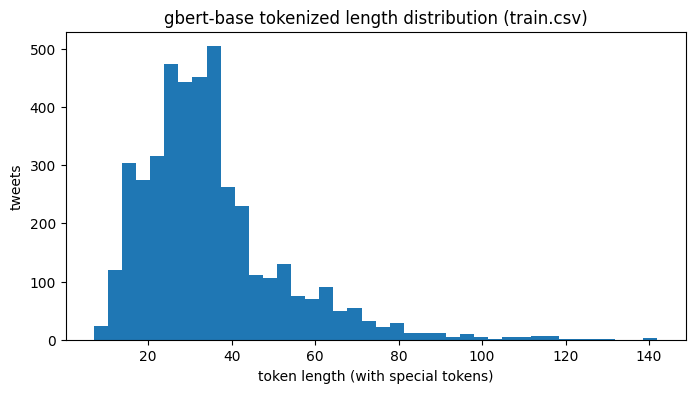

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(token_lengths, bins=40)
plt.xlabel("token length (with special tokens)")
plt.ylabel("tweets")
plt.title("gbert-base tokenized length distribution (train.csv)")
plt.show()

**Decision:** as shown above, the vast majority of tweets tokenize well
under 128 tokens, and only a small handful of outliers exceed it.
`MAX_LENGTH = 128` is used

In [5]:
MAX_LENGTH = 128

## 2. Fine-tuning configuration

Fixed for every seed:

| hyperparameter | value |
|---|---|
| checkpoint | `deepset/gbert-base` |
| max sequence length | `MAX_LENGTH` (128, see above) |
| batch size | `config.FINE_TUNE_BATCH_SIZE` |
| learning rate | `config.FINE_TUNE_LR` |
| weight decay | `config.FINE_TUNE_WEIGHT_DECAY` |
| epochs | `config.FINE_TUNE_EPOCHS` |
| optimizer | AdamW, linear schedule with 10% warmup |
| checkpoint selection | best **val macro-F1** across epochs |

Three seeds (`config.FINE_TUNE_SEEDS`) are fine-tuned independently so
later analysis has a variance estimate, not a single point value. Only the
classification head's initialization, dropout, and data-loader shuffling
differ across seeds. The pretrained encoder weights start identical
every time (`src/transformer_models.py`, `load_model_and_tokenizer`).

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

if device.type != "cuda":
    print(
        "Note: no GPU detected — check that this Colab runtime has a GPU "
        "attached (Runtime > Change runtime type)."
    )

device: cuda


## 3. Sanity check before the full run

Before committing to the full multi-seed fine-tuning loop, this cell
tokenizes a tiny 8-example slice, builds one batch, loads `gbert-base`
with a fresh classification head, and runs a **single forward pass**.
This only checks that shapes, label encoding, and the loss computation
are wired correctly — it is not a training run.

The "Some weights ... were newly initialized" message below is expected:
it refers to the classification head, which is never part of the
pretrained checkpoint and always starts randomly initialized.

In [7]:
tiny_texts = list(train_df["text"].iloc[:8])
tiny_labels = list(train_df["label"].iloc[:8])

sanity_model, sanity_tokenizer = transformer_models.load_model_and_tokenizer(config.TRANSFORMER_CHECKPOINT, seed=config.SEED)
sanity_dataset = transformer_models.GermEvalDataset(tiny_texts, tiny_labels, sanity_tokenizer, max_length=MAX_LENGTH)
sanity_loader = torch.utils.data.DataLoader(sanity_dataset, batch_size=4, shuffle=False)

sanity_batch = next(iter(sanity_loader))
sanity_outputs = sanity_model(**sanity_batch)

print("input_ids shape:", sanity_batch["input_ids"].shape)
print("loss:", sanity_outputs.loss.item())
print("logits shape:", sanity_outputs.logits.shape)

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at deepset/gbert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


input_ids shape: torch.Size([4, 128])
loss: 0.7356078028678894
logits shape: torch.Size([4, 2])


## 4. Multi-seed fine-tuning

Each seed fine-tunes an independent copy of `gbert-base` end to end
(`src/transformer_models.run_finetuning`), keeps the epoch with the best validation
macro-F1, and saves the model, tokenizer, and per-epoch training history
to `results/transformer/gbert-base/seed_{seed}/`. Once this finishes,
sync that `results/transformer/` folder back into the local repository so
notebook 06 can load it.

In [8]:
histories = {}

for seed in config.FINE_TUNE_SEEDS:
    print(f"=== seed {seed} ===")
    output_dir = config.RESULTS_DIR / "transformer" / config.TRANSFORMER_MODEL_NAME / f"seed_{seed}"
    history_df = transformer_models.run_finetuning(
        checkpoint=config.TRANSFORMER_CHECKPOINT,
        train_df=train_df,
        val_df=val_df,
        seed=seed,
        max_length=MAX_LENGTH,
        batch_size=config.FINE_TUNE_BATCH_SIZE,
        lr=config.FINE_TUNE_LR,
        weight_decay=config.FINE_TUNE_WEIGHT_DECAY,
        num_epochs=config.FINE_TUNE_EPOCHS,
        output_dir=output_dir,
        device=device,
    )
    histories[seed] = history_df
    print(history_df)

=== seed 42 ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at deepset/gbert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   epoch  train_loss  val_macro_f1
0      1    0.510312      0.780287
1      2    0.310004      0.825586
2      3    0.147256      0.812974
3      4    0.062716      0.813412
=== seed 123 ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at deepset/gbert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   epoch  train_loss  val_macro_f1
0      1    0.498069      0.811117
1      2    0.304677      0.817408
2      3    0.153371      0.815646
3      4    0.066513      0.810778
=== seed 67 ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at deepset/gbert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   epoch  train_loss  val_macro_f1
0      1    0.518519      0.801472
1      2    0.309268      0.806409
2      3    0.147609      0.817454
3      4    0.066363      0.827637


## 5. Cross-seed summary

The best epoch (by val macro-F1) from each seed is collected into one
table, and the mean/standard deviation across seeds is reported as the
transformer's validation performance — directly comparable to the single
baseline number from notebook 04, but with a variance estimate this
time.

In [9]:
best_rows = []
for seed, history_df in histories.items():
    best_row = history_df.loc[history_df["val_macro_f1"].idxmax()].copy()
    best_row["seed"] = seed
    best_rows.append(best_row)

summary_df = pd.DataFrame(best_rows)[["seed", "epoch", "train_loss", "val_macro_f1"]]
summary_df.to_csv(config.RESULTS_DIR / "transformer" / config.TRANSFORMER_MODEL_NAME / "summary.csv", index=False)

print(f"val macro-F1: {summary_df['val_macro_f1'].mean():.4f} ± {summary_df['val_macro_f1'].std():.4f}")
summary_df

val macro-F1: 0.8235 ± 0.0054


    seed  epoch  train_loss  val_macro_f1
1   42.0    2.0    0.310004      0.825586
1  123.0    2.0    0.304677      0.817408
3   67.0    4.0    0.066363      0.827637